In [18]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append('../src')
from pre_processing import df_transform_experimental, prepare_for_training
import os
os.environ["WANDB_SILENT"] = "true"
import wandb
import pandas as pd

DATA_PATH = '../data/train.csv'
CLASS_NAMES = ["Clutter", "Cormorants", "Pigeons", "Ducks", "Geese", "Gulls", "Birds of Prey", "Waders", "Songbirds"]

from feature_config import features_config

df = pd.read_csv(DATA_PATH)
transformed = df_transform_experimental(df, features_config, True)
X, y, features = prepare_for_training(transformed, features_config, CLASS_NAMES)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from xgboost_train import run_cv_training_xgboost
from custom_scoring import calculate_macro_ap

params = {
            'n_estimators': 1428,
            'learning_rate': 0.05,
            'subsample': 0.6,
            'gamma': 5,
            'max_depth': 5,
            'min_child_weight': 5,
            'objective': 'multi:softprob',
            'num_class': len(CLASS_NAMES),
            'tree_method': 'hist',
            'early_stopping_rounds': 180,
            'random_state': 42,
            'use_weights': True,
            'resampling': False,
        }

config = {
    'params':params,
    'feature_version':features,
}

wandb.init(project="AICup", config=config)
models, oof_preds= run_cv_training_xgboost(X, y, class_names=CLASS_NAMES, params=params)
#models, oof_preds= run_cv_training_cat(X, y, class_names=CLASS_NAMES)
final_score, detailed_scores = calculate_macro_ap(y, oof_preds, CLASS_NAMES)
wandb.log({"mean_macro_ap": final_score})
wandb.log({"detailed_scores": detailed_scores})
wandb.finish()

print(final_score)


from result_analysis import debug_per_class_scores

debug_per_class_scores(y, oof_preds)

Fold 1: | Iter 1359 | Train mlogloss: 0.2554 | Val mlogloss: 0.0278
Fold 2: | Iter 1175 | Train mlogloss: 0.2652 | Val mlogloss: 0.0151
Fold 3: | Iter 988 | Train mlogloss: 0.2478 | Val mlogloss: 0.0591
Fold 4: | Iter 1298 | Train mlogloss: 0.2470 | Val mlogloss: 0.0218
Fold 5: | Iter 1221 | Train mlogloss: 0.2603 | Val mlogloss: 0.0159
0.6173714598749199

--- Per-Class Performance ---


,Class,AP_Score,Support
0,Clutter,0.916309,84
5,Gulls,0.914183,1503
2,Pigeons,0.860535,122
8,Songbirds,0.677299,483
4,Geese,0.577725,83
6,Birds of Prey,0.497560,108
3,Ducks,0.486263,58
7,Waders,0.460805,120
1,Cormorants,0.165664,40


In [12]:
from kaggle_prediction import generate_ensemble_submission

generate_ensemble_submission(models, features_config, class_names=CLASS_NAMES)

Generating predictions for model 1/5...
Generating predictions for model 2/5...
Generating predictions for model 3/5...
Generating predictions for model 4/5...
Generating predictions for model 5/5...
Ensemble submission saved to: ../submissions/submission.csv


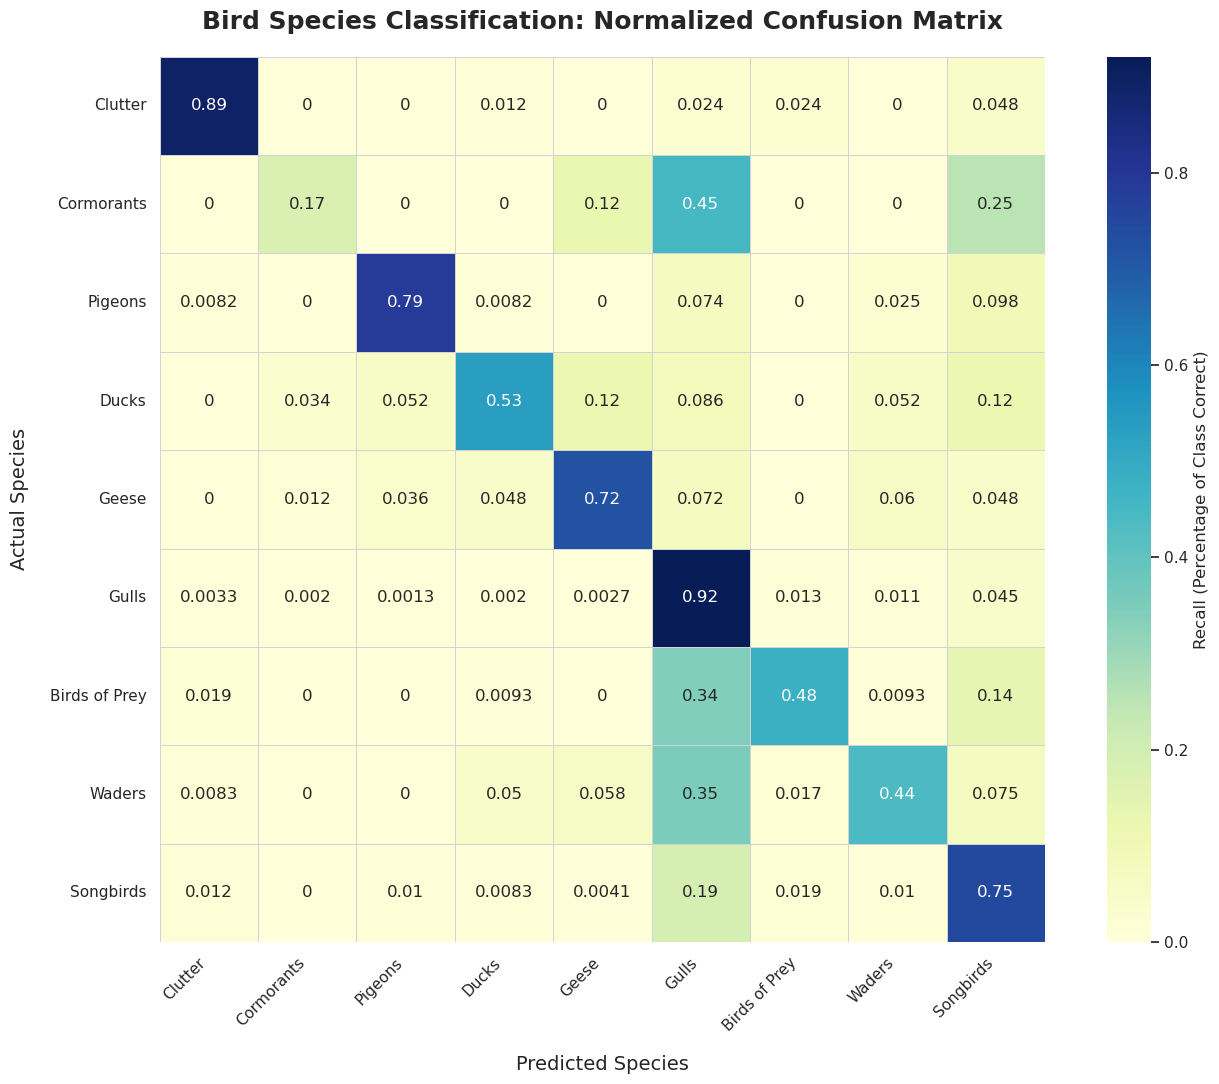

In [13]:
from result_analysis import plot_bird_confusion_pretty
plot_bird_confusion_pretty(y ,oof_preds, class_names=CLASS_NAMES)

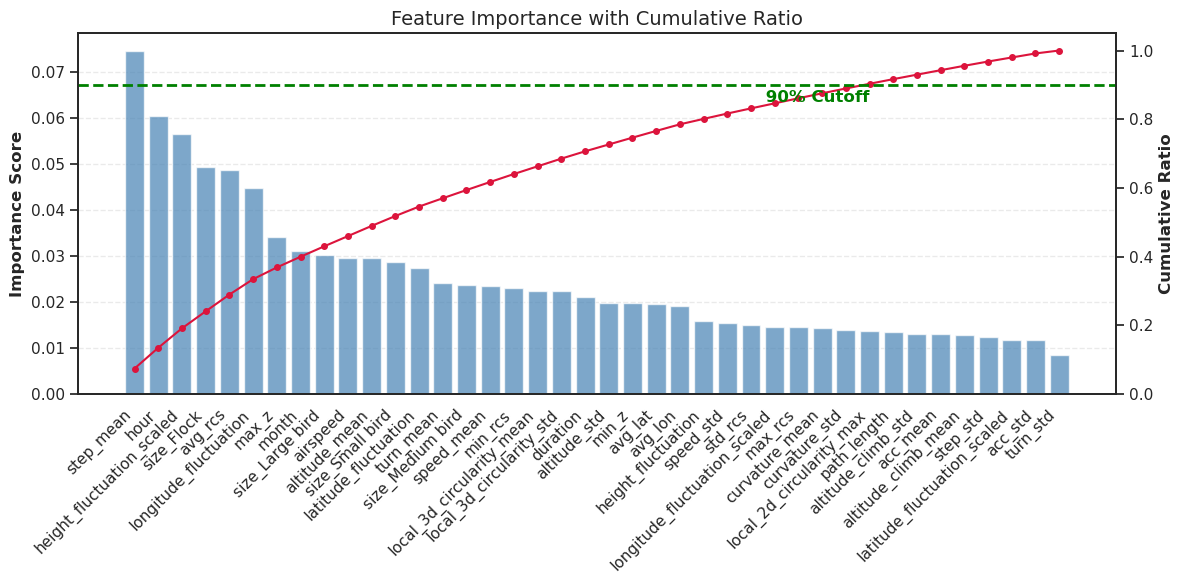

In [5]:
from result_analysis import plot_cumulative_importance
plot_cumulative_importance(models, features)

# Grid Search

In [16]:
import scipy.stats as stats
from xgboost_train import grid_search

param_distributions = {
    'learning_rate': stats.uniform(0.1, 0.1),

    'n_estimators': [1400],
    'max_depth': [5],
    'min_child_weight': stats.randint(1, 10),
    'subsample': stats.uniform(0.6, 0.4),
    'objective': ['multi:softprob'],
    'num_class': [len(CLASS_NAMES)],
    'tree_method': ['hist'],
    'early_stopping_rounds': [150],
    'random_state': [42],
    'use_weights': [True],
    'resampling': [False],
}

#grid_search(X, y, CLASS_NAMES, param_distributions, features)

Starting Random Search for 10 iterations...

--- Iteration 1/10 ---
Testing parameters: {'early_stopping_rounds': 150, 'learning_rate': 0.13745401188473627, 'max_depth': 5, 'min_child_weight': 8, 'n_estimators': 1400, 'num_class': 9, 'objective': 'multi:softprob', 'random_state': 42, 'resampling': False, 'subsample': 0.8394633936788146, 'tree_method': 'hist', 'use_weights': True}
Fold 1 | Best Iter: 118 | Score: 0.6629
Fold 2 | Best Iter: 141 | Score: 0.6700
Fold 3 | Best Iter: 194 | Score: 0.7149
Fold 4 | Best Iter: 316 | Score: 0.7098
Fold 5 | Best Iter: 440 | Score: 0.7059
Achieved mean_macro_ap: 0.6739

--- Iteration 2/10 ---
Testing parameters: {'early_stopping_rounds': 150, 'learning_rate': 0.11560186404424366, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 1400, 'num_class': 9, 'objective': 'multi:softprob', 'random_state': 42, 'resampling': False, 'subsample': 0.6399899663272012, 'tree_method': 'hist', 'use_weights': True}
Fold 1 | Best Iter: 146 | Score: 0.7056
Fold 2 

In [6]:
sweep_config = {
    'method': 'grid', 
    'metric': {'name': 'mean_macro_ap', 'goal': 'maximize'},
    'parameters': {
        'learning_rate': {'values': [0.03, 0.05, 0.1]},
        'max_depth': {'values': [4, 6, 8]},
        'n_estimators': {'values': [1000]},
        'use_weights': {'values': [True, False]}
    }
}

#sweep_id = wandb.sweep(sweep_config, project="AICup")

def sweep_train():
    with wandb.init() as run:
        current_params = wandb.config
        models, oof_preds = run_cv_training_xgboost(
            X, y, 
            class_names=CLASS_NAMES, 
            params=current_params
        )

        final_score, detailed_scores = calculate_macro_ap(y, oof_preds, CLASS_NAMES)

        wandb.log({
            "mean_macro_ap": final_score,
            "detailed_scores": detailed_scores
        })

#wandb.agent(sweep_id, function=sweep_train)